In [1]:
import os
import cv2
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
from zipfile import ZipFile

with ZipFile('archive (3).zip', 'r') as zip_ref:

    zip_ref.extractall('/content')

In [3]:
data = []

labels = []

categories = ['cats', 'dogs']

path = '/content/training_set/training_set'

for category in categories:

    folder = os.path.join(path, category)

    label = categories.index(category)

    count = 0

    for image in os.listdir(folder):

        if count == 500:

            break

        try:

            img_path = os.path.join(folder, image)

            img = cv2.imread(img_path)

            img = cv2.resize(img, (64,64))

            data.append(img.flatten())

            labels.append(label)

            count += 1

        except:

            pass

In [4]:
X = np.array(data)

y = np.array(labels)

print(X.shape)

print(y.shape)

(1000, 12288)
(1000,)


In [5]:
print("Images Loaded:", len(X))

print("Labels Loaded:", len(y))

print(X.shape)

print(y.shape)

Images Loaded: 1000
Labels Loaded: 1000
(1000, 12288)
(1000,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42
)

In [7]:
model = SVC(

    kernel='linear'

)

model.fit(

    X_train,

    y_train
)

SVC(kernel='linear')

In [8]:
y_pred = model.predict(

    X_test
)

In [9]:
print(

    classification_report(

        y_test,

        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.53      0.66      0.59        96
           1       0.60      0.47      0.53       104

    accuracy                           0.56       200
   macro avg       0.57      0.56      0.56       200
weighted avg       0.57      0.56      0.56       200



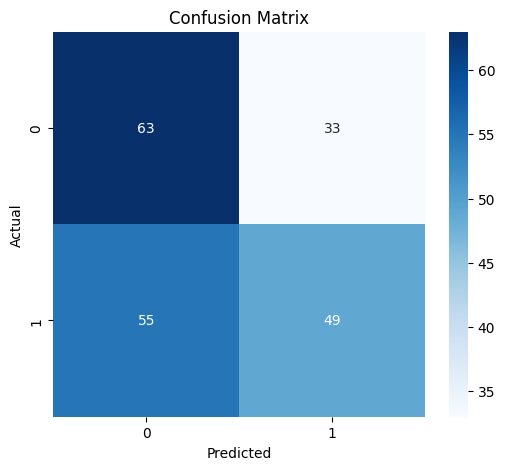

In [10]:
cm = confusion_matrix(

    y_test,

    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

In [11]:
sample = X_test[0]

prediction = model.predict(

    sample.reshape(1,-1)
)

if prediction[0] == 0:

    print("Cat")

else:

    print("Dog")

Cat
